--- Generating Plot 1: H1 Multi-Condition Evaluation ---
QWEN72B: Original=38.7%, DomainShift=38.7%, Caroline=34.3%
QWEN: Original=57.4%, DomainShift=55.9%, Caroline=56.4%
GEMMA: Original=52.5%, DomainShift=53.4%, Caroline=48.5%
MISTRAL: Original=44.6%, DomainShift=41.7%, Caroline=44.1%
H1 Plot saved as Vector PDF: /kaggle/working/results/h1_accuracy_drop_all_models.pdf


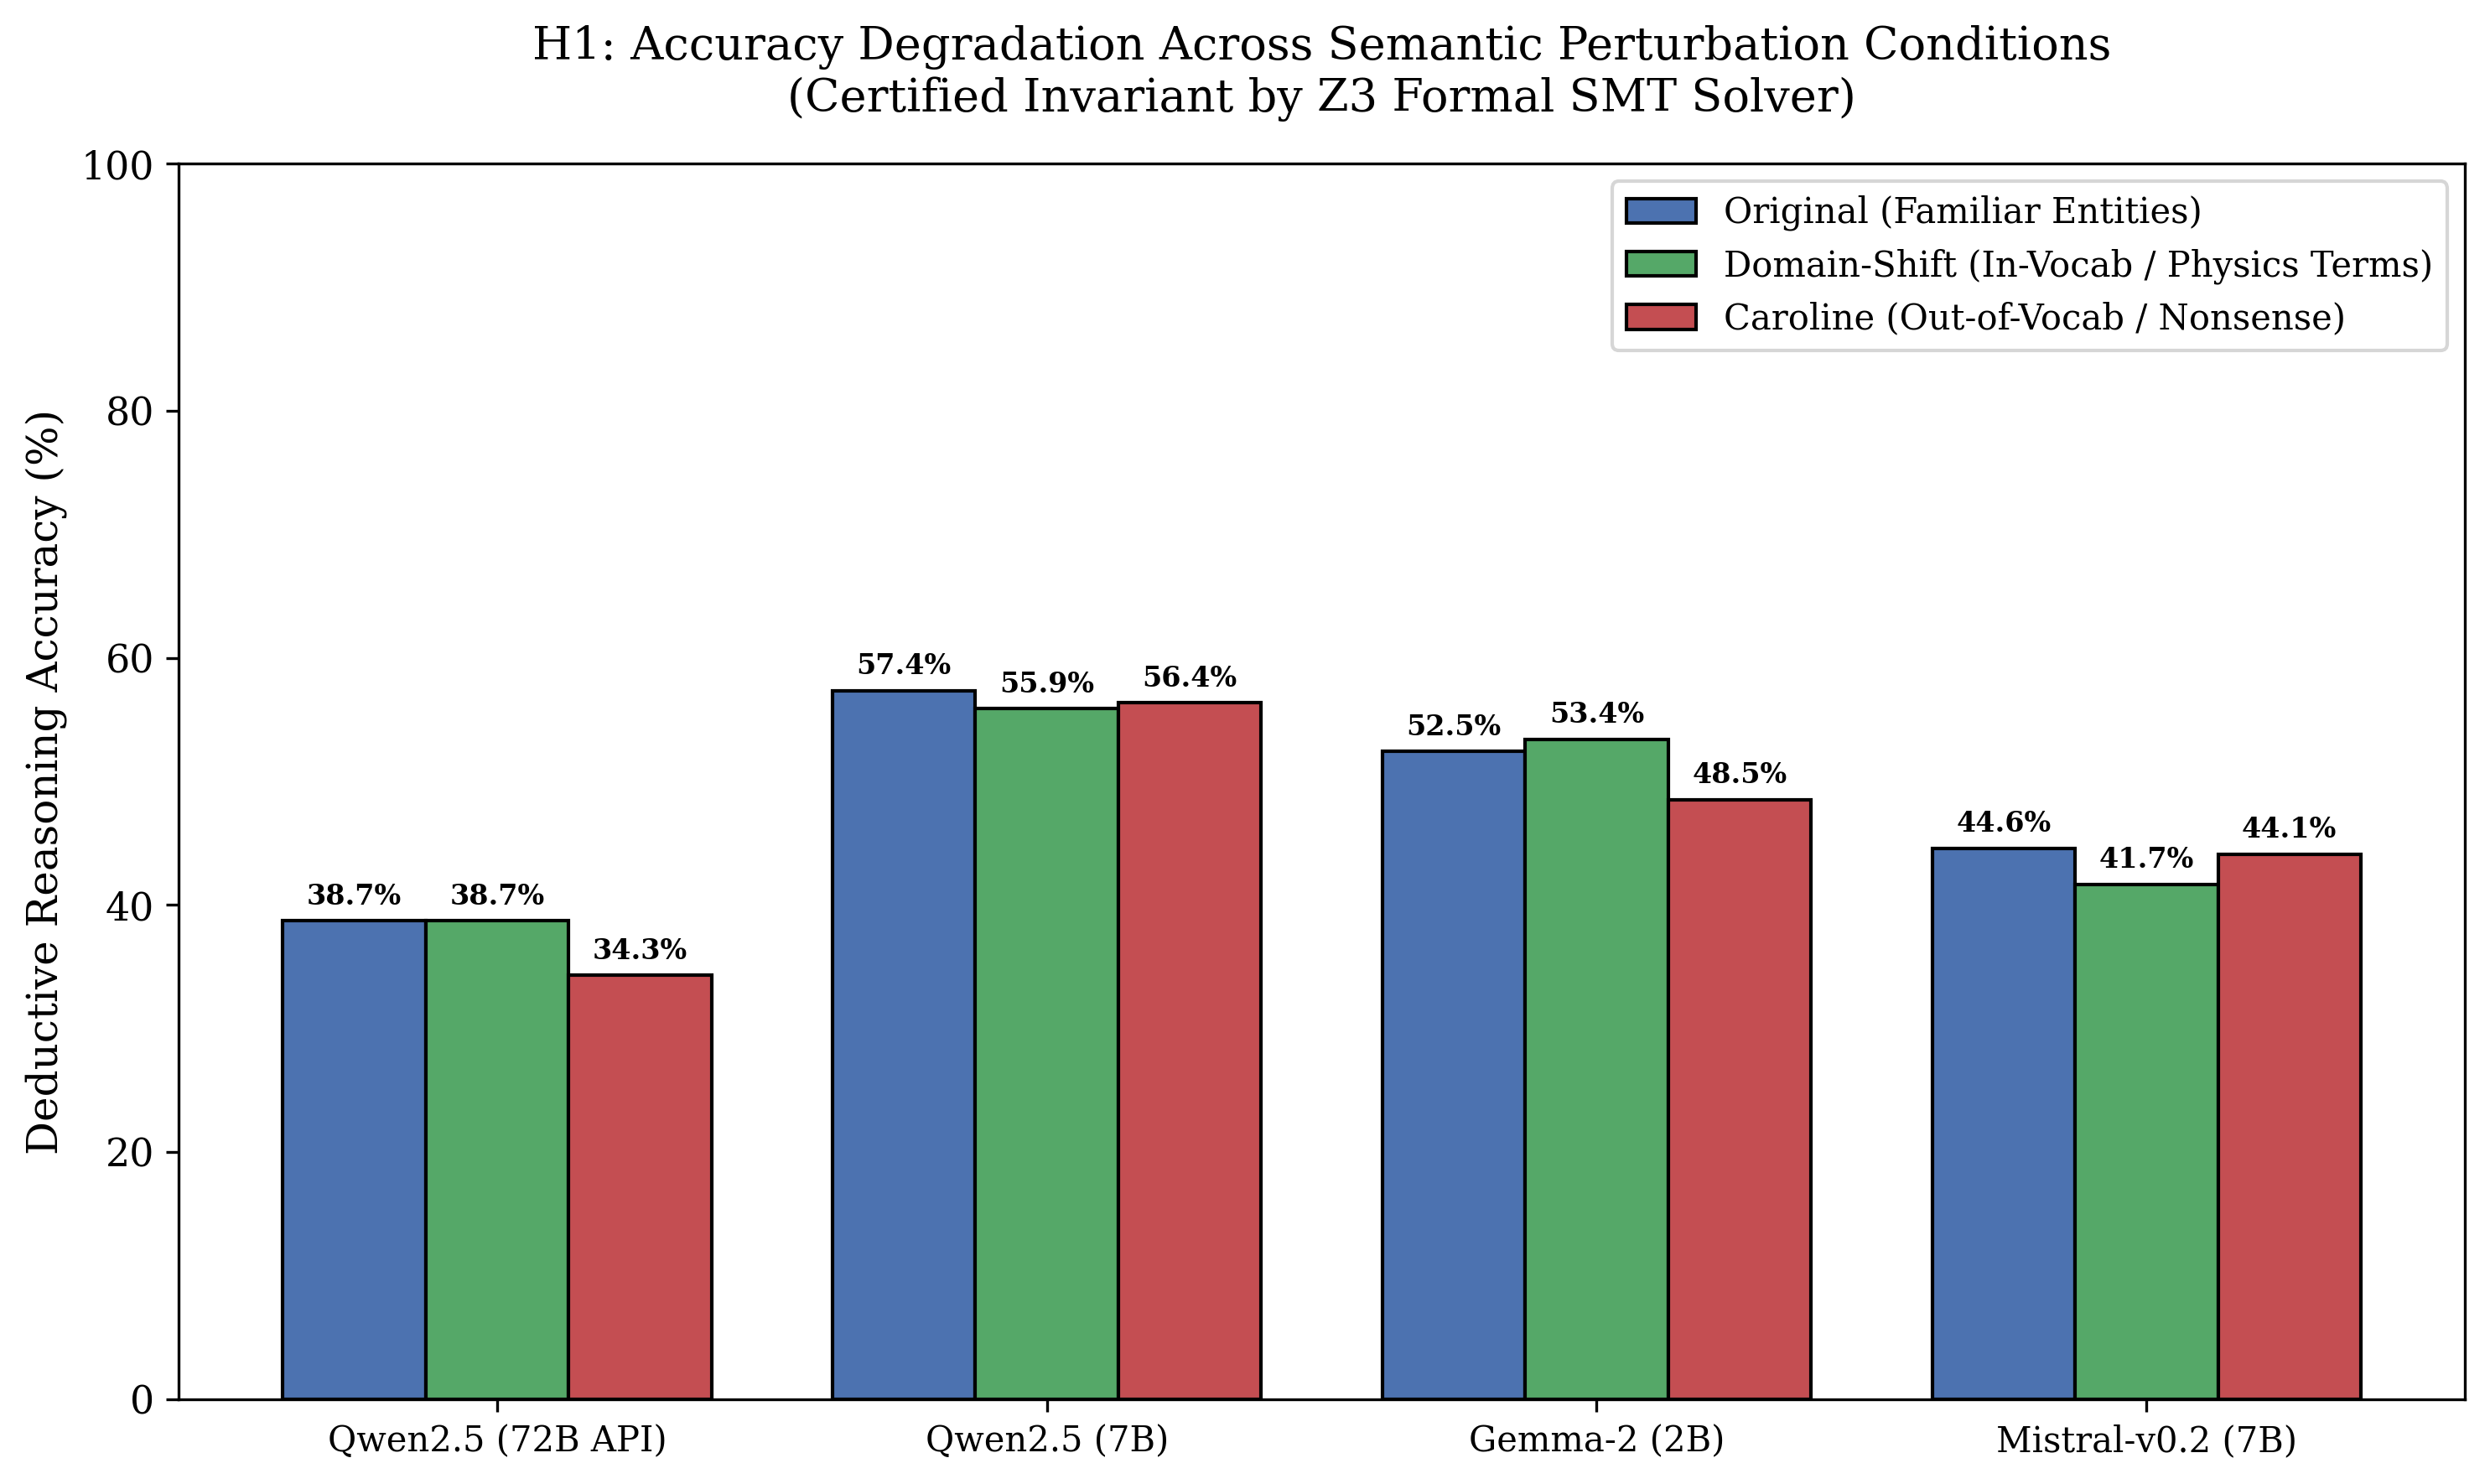


--- Generating Plot 2: H2 Length-Normalized Surprisal ---
H2 Plot saved as Vector PDF: /kaggle/working/results/h2_surprisal_inconsistency_all_models.pdf


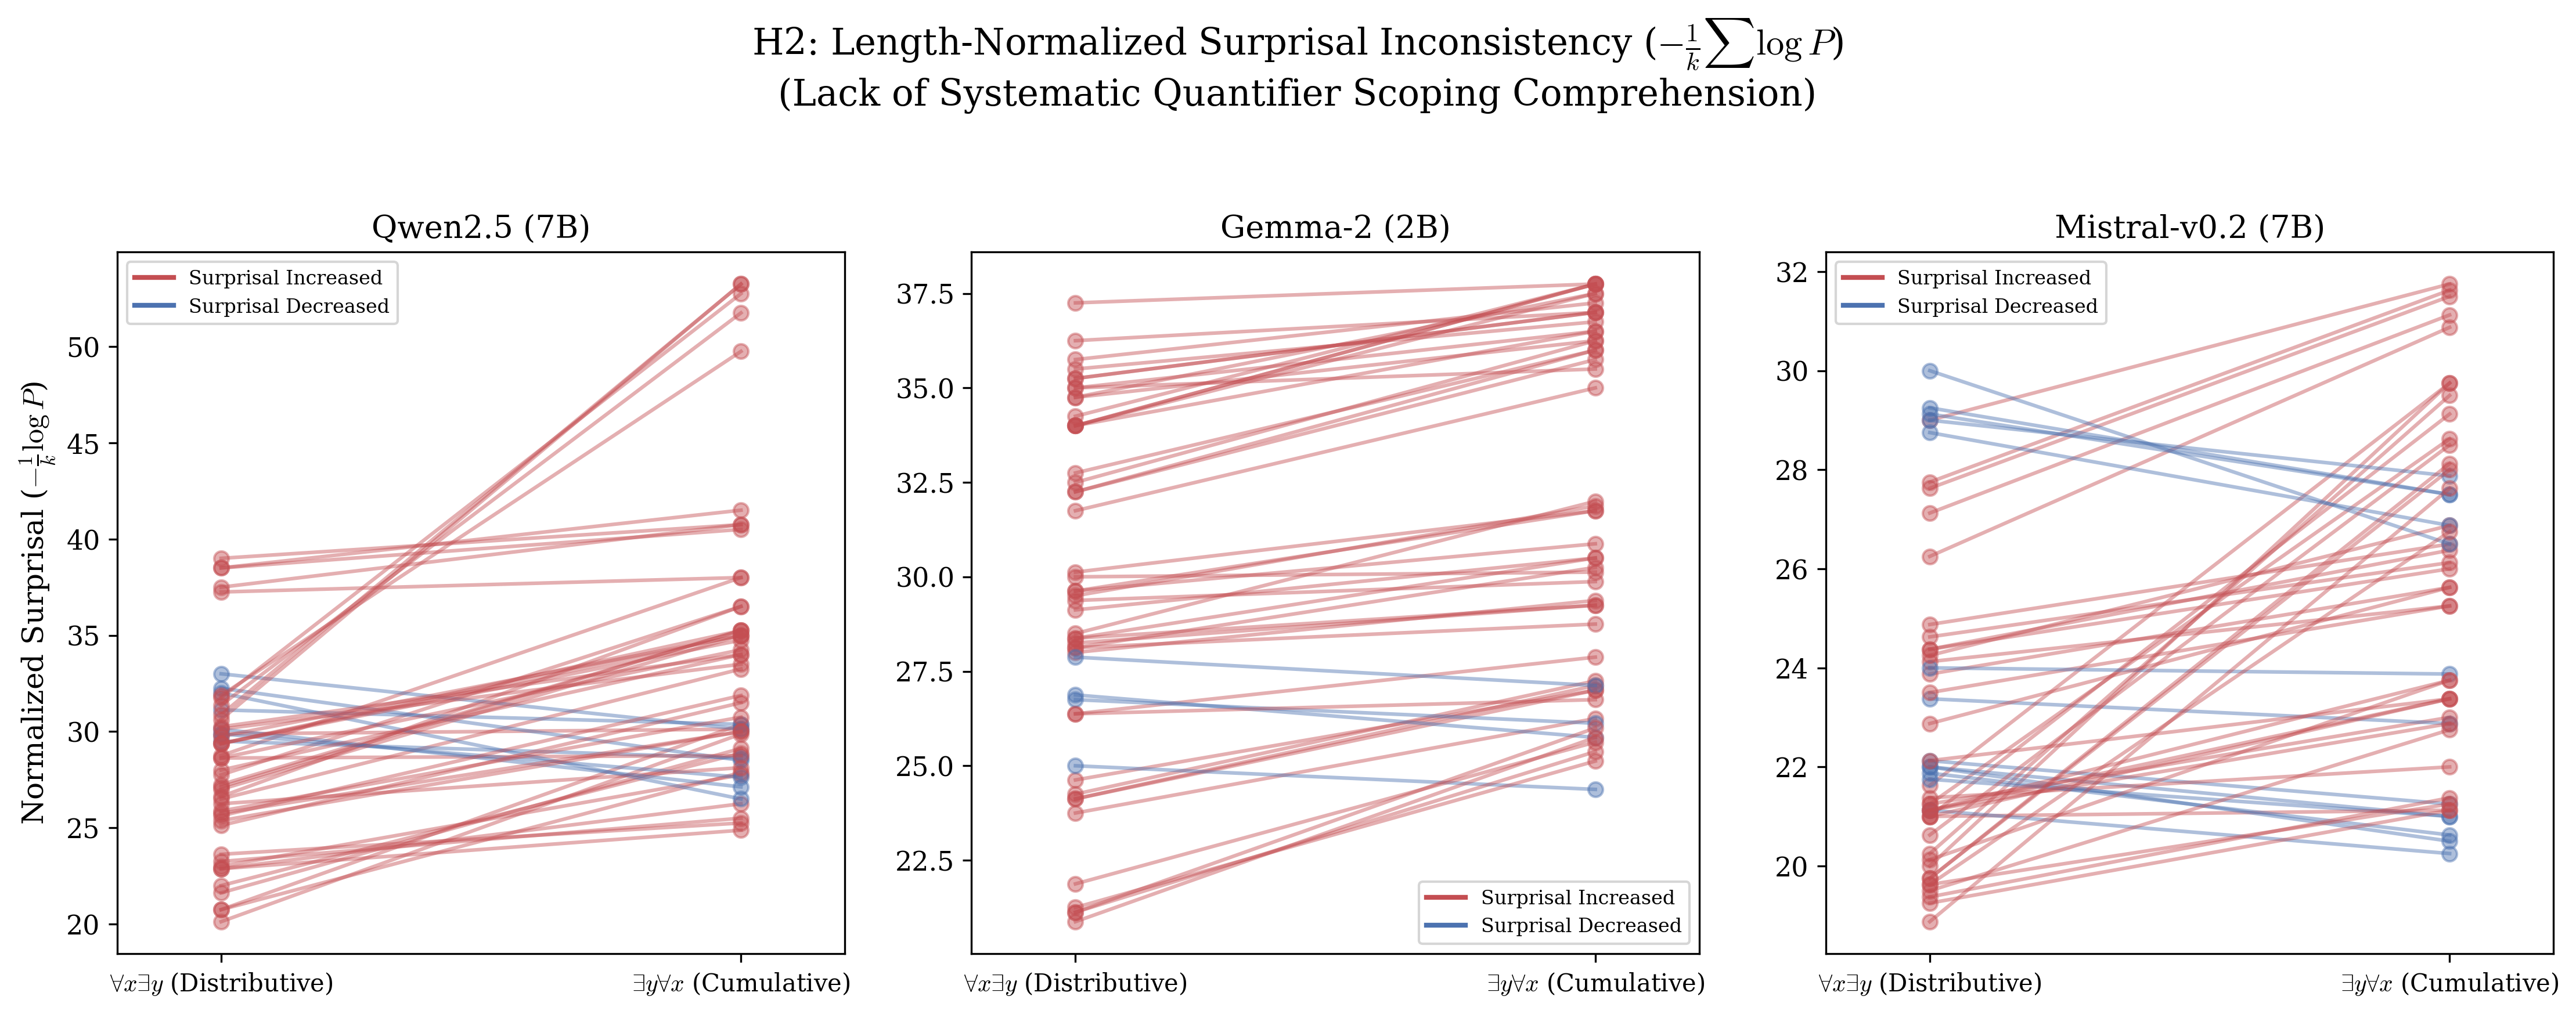


All statistical vector plots generated successfully!


In [1]:
!pip install pandas matplotlib numpy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================================================
# 1. ACADEMIC PLOTTING CONFIGURATION (LATEX SERIF STYLE)
# =========================================================
plt.rcParams.update({
    "font.family": "serif",        
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "text.usetex": False,          
    "mathtext.fontset": "cm",      
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 300              
})

OUTPUT_RESULTS_DIR = '/kaggle/working/results'
os.makedirs(OUTPUT_RESULTS_DIR, exist_ok=True)

# Exact Dataset Paths Provided by User
h1_dir = '/kaggle/input/datasets/alirezaebrahimi/folio-h1-llm-answers' 
h2_file = '/kaggle/input/datasets/alirezaebrahimi/folio-h2-surprisal-data/surprisal_results_h2_all_models.csv'

# =========================================================
# 2. PLOT 1: H1 MULTI-CONDITION ACCURACY EVALUATION (4 MODELS)
# =========================================================
print("--- Generating Plot 1: H1 Multi-Condition Evaluation ---", flush=True)

models = ['qwen72b', 'qwen', 'gemma', 'mistral']
model_labels = ['Qwen2.5 (72B API)', 'Qwen2.5 (7B)', 'Gemma-2 (2B)', 'Mistral-v0.2 (7B)']

acc_orig = []
acc_domain = []
acc_caroline = []
valid_models = []
valid_labels = []

for m, label_name in zip(models, model_labels):
    # Check potential filename variants
    candidate_paths = [
        os.path.join(h1_dir, f'llm_answers_h1_v2_{m}.csv'),
        os.path.join(h1_dir, f'llm_answers_h1_{m}.csv')
    ]
    
    fpath = None
    for cp in candidate_paths:
        if os.path.exists(cp):
            fpath = cp
            break
            
    if fpath is None:
        print(f"[Warning]: Could not locate CSV for model '{m}' in {h1_dir}. Skipping...", flush=True)
        continue
        
    df_h1 = pd.read_csv(fpath)
    gt_label = df_h1['label'].astype(str).str.strip().str.capitalize()
    
    # Calculate accuracy across Original, Domain-Shift, and Caroline conditions
    a_orig = (gt_label == df_h1['ans_orig_zero'].astype(str).str.strip().str.capitalize()).mean() * 100
    a_dom = (gt_label == df_h1['ans_domain_zero'].astype(str).str.strip().str.capitalize()).mean() * 100
    a_caro = (gt_label == df_h1['ans_caroline_zero'].astype(str).str.strip().str.capitalize()).mean() * 100
    
    acc_orig.append(a_orig)
    acc_domain.append(a_dom)
    acc_caroline.append(a_caro)
    valid_models.append(m)
    valid_labels.append(label_name)
    
    print(f"{m.upper()}: Original={a_orig:.1f}%, DomainShift={a_dom:.1f}%, Caroline={a_caro:.1f}%", flush=True)

# Plot Grouped Bar Chart
fig1, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(valid_models))
width = 0.26

r1 = ax1.bar(x - width, acc_orig, width, label='Original (Familiar Entities)', color='#4C72B0', edgecolor='black')
r2 = ax1.bar(x, acc_domain, width, label='Domain-Shift (In-Vocab / Physics Terms)', color='#55A868', edgecolor='black')
r3 = ax1.bar(x + width, acc_caroline, width, label='Caroline (Out-of-Vocab / Nonsense)', color='#C44E52', edgecolor='black')

ax1.set_ylabel('Deductive Reasoning Accuracy (%)')
ax1.set_title('H1: Accuracy Degradation Across Semantic Perturbation Conditions\n(Certified Invariant by Z3 Formal SMT Solver)', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(valid_labels)
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right')

def add_bar_labels(rects):
    for rect in rects:
        h = rect.get_height()
        ax1.annotate(f'{h:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

add_bar_labels(r1)
add_bar_labels(r2)
add_bar_labels(r3)

plt.tight_layout()
h1_pdf_path = os.path.join(OUTPUT_RESULTS_DIR, 'h1_accuracy_drop_all_models.pdf')
plt.savefig(h1_pdf_path, format='pdf', bbox_inches='tight')
print(f"H1 Plot saved as Vector PDF: {h1_pdf_path}", flush=True)
plt.show()

# =========================================================
# 3. PLOT 2: H2 LENGTH-NORMALIZED SURPRISAL SLOPEGRAPHS
# =========================================================
print("\n--- Generating Plot 2: H2 Length-Normalized Surprisal ---", flush=True)

df_h2 = pd.read_csv(h2_file)
h2_models = ['qwen', 'gemma', 'mistral']
h2_labels = ['Qwen2.5 (7B)', 'Gemma-2 (2B)', 'Mistral-v0.2 (7B)']

fig2, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=False)
fig2.suptitle(r'H2: Length-Normalized Surprisal Inconsistency ($-\frac{1}{k}\sum \log P$)' + '\n(Lack of Systematic Quantifier Scoping Comprehension)', fontsize=15, y=1.05)

unique_pairs = df_h2['pair_id'].unique()
from matplotlib.lines import Line2D
custom_legend = [Line2D([0], [0], color='#C44E52', lw=2), Line2D([0], [0], color='#4C72B0', lw=2)]

for idx, m in enumerate(h2_models):
    ax = axes[idx]
    col = f'surprisal_score_{m}'
    
    for pid in unique_pairs:
        subset = df_h2[df_h2['pair_id'] == pid]
        if len(subset) == 2:
            dist = subset[subset['scope_type'].str.contains('Distributive')][col].values[0]
            cum = subset[subset['scope_type'].str.contains('Cumulative')][col].values[0]
            
            line_color = '#C44E52' if cum > dist else '#4C72B0'
            ax.plot([1, 2], [dist, cum], marker='o', color=line_color, alpha=0.45, linewidth=1.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([r'$\forall x \exists y$ (Distributive)', r'$\exists y \forall x$ (Cumulative)'])
    ax.set_title(h2_labels[idx])
    ax.set_xlim(0.8, 2.2)
    if idx == 0:
        ax.set_ylabel(r'Normalized Surprisal ($-\frac{1}{k}\log P$)')
    ax.legend(custom_legend, ['Surprisal Increased', 'Surprisal Decreased'], loc='best', fontsize=8)

plt.tight_layout()
h2_pdf_path = os.path.join(OUTPUT_RESULTS_DIR, 'h2_surprisal_inconsistency_all_models.pdf')
plt.savefig(h2_pdf_path, format='pdf', bbox_inches='tight')
print(f"H2 Plot saved as Vector PDF: {h2_pdf_path}", flush=True)
plt.show()

print("\nAll statistical vector plots generated successfully!", flush=True)